In [105]:
import numpy as np
import matplotlib.pyplot as plt

In [106]:
np.random.seed(42)
m=100
X=2*np.random.rand(m,1)
y=4+3*X+np.random.randn(m,1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


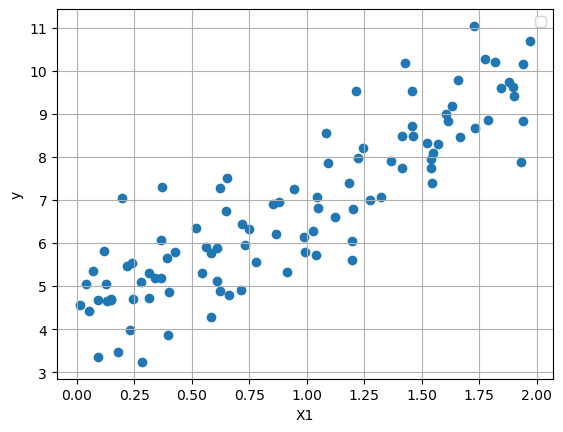

In [117]:
plt.scatter(X,y)
plt.xlabel("X1")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

In [118]:
from sklearn.preprocessing import add_dummy_feature

X_b=add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b)@X_b.T@y

In [119]:
theta_best

array([[4.21509616],
       [2.77011339]])

In [120]:
X_new  = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
X_new_b

array([[1., 0.],
       [1., 2.]])

In [121]:
y_predict

array([[4.21509616],
       [9.75532293]])

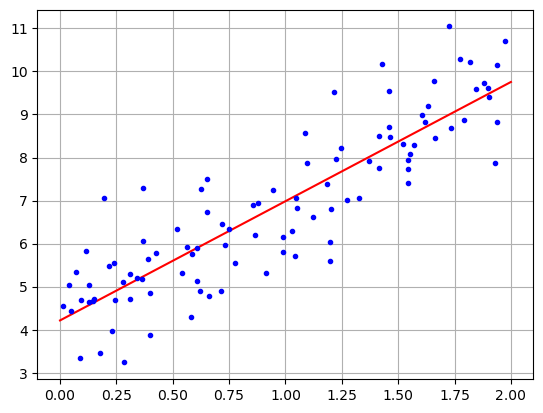

In [122]:
import matplotlib.pyplot as plt

plt.plot(X_new,y_predict,'r-',label="Predictions")
plt.plot(X,y,'b.')
plt.grid()

In [123]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [124]:
lin_reg.intercept_,lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [125]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

In [126]:
theta_best_svd,residuals,rank,s= np.linalg.lstsq(X_b,y,rcond=1e-6)

In [127]:
theta_best_svd

array([[4.21509616],
       [2.77011339]])

In [128]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

## Gradient Descent

### Batch Gradient Descent

In [142]:
eta = 0.1 # learning rate
n_epochs = 1000
m = len(X_b)

np.random.seed(42)
theta_0 = []
theta_1 = []

theta = np.random.randn(2,1)
for epoch in range(n_epochs):
    theta_0.append(list(theta[0]))
    theta_1.append(list(theta[1]))
    gradients = 2/m * X_b.T@(X_b@theta-y )
    theta = theta - eta * gradients


In [143]:
theta

array([[4.21509616],
       [2.77011339]])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


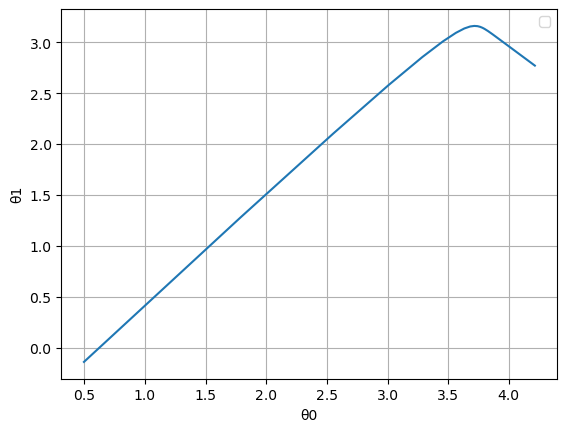

In [144]:
plt.plot(theta_0,theta_1)
plt.xlabel("θ0")
plt.ylabel("θ1")
plt.grid()
plt.legend()

### Stochastic Gradient Descent 

In [145]:
X_b

array([[1.        , 0.74908024],
       [1.        , 1.90142861],
       [1.        , 1.46398788],
       [1.        , 1.19731697],
       [1.        , 0.31203728],
       [1.        , 0.31198904],
       [1.        , 0.11616722],
       [1.        , 1.73235229],
       [1.        , 1.20223002],
       [1.        , 1.41614516],
       [1.        , 0.04116899],
       [1.        , 1.9398197 ],
       [1.        , 1.66488528],
       [1.        , 0.42467822],
       [1.        , 0.36364993],
       [1.        , 0.36680902],
       [1.        , 0.60848449],
       [1.        , 1.04951286],
       [1.        , 0.86389004],
       [1.        , 0.58245828],
       [1.        , 1.22370579],
       [1.        , 0.27898772],
       [1.        , 0.5842893 ],
       [1.        , 0.73272369],
       [1.        , 0.91213997],
       [1.        , 1.57035192],
       [1.        , 0.39934756],
       [1.        , 1.02846888],
       [1.        , 1.18482914],
       [1.        , 0.09290083],
       [1.

In [177]:
n_epochs = 50
t0,t1=5,50

def learning_schedule(t):
    return t0/(t+t1)

np.random.seed(42)
theta = np.random.randn(2,1)
theta_0 = []
theta_1 = []
for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T @ (xi@theta-yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta-eta*gradients
        theta_0.append(list(theta[0]))
        theta_1.append(list(theta[1]))

In [178]:
theta

array([[4.21076011],
       [2.74856079]])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


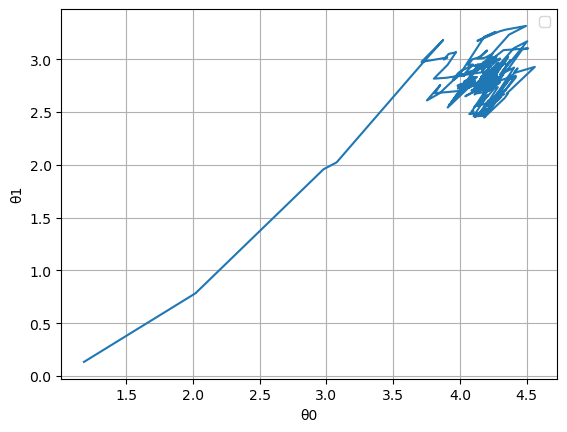

In [179]:
plt.plot(theta_0,theta_1)
plt.xlabel("θ0")
plt.ylabel("θ1")
plt.grid()
plt.legend()